<a href="https://colab.research.google.com/github/alexfergh2025-ops/TAREA_DesviacionEstatandar/blob/main/EjercicioPropuesto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EJERCICIO PROPUESTO: Análisis de Defectos en Ingeniería de Software mediante Diagrama de Pareto
1. **Enunciado del ejercicio**

Un equipo de desarrollo de software está evaluando la calidad del último módulo de un sistema empresarial. Durante las pruebas de integración, el equipo de QA registró todos los defectos encontrados y los clasificó según su tipo.

El líder del proyecto solicita realizar un **Diagrama de Pareto** para identificar cuáles son los tipos de defectos que generan el mayor impacto en el proyecto y así poder priorizar acciones correctivas para el siguiente sprint.

Los datos recopilados son los siguientes:

| **Tipo de defecto** | **Frecuencia** |
| --- | --- |
| Problemas de rendimiento | 17 |
| Errores en interfaz de usuario (UI) | 38 |
| Configuración incorrecta del entorno | 9 |
| Errores de validación | 57 |
| Excepciones no controladas | 22 |
| Otros | 6 |
| Fallas en lógica de negocio | 45 |
| Errores de conexión a la base de datos | 14 |

Se pide a los estudiantes:

1. Construir el **Diagrama de Pareto**.
2. Identificar cuáles son las **pocas causas vitales** (≈80% del impacto).
3. Analizar cómo estos defectos afectan al proyecto.
4. Plantear **propuestas de mejora** para los próximos sprints.
5. Crear el gráfico en **Python + Colab**.

In [8]:
#IMPORTAR LIBRERIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files



### Solución al Ejercicio Propuesto: Análisis de Defectos en Ingeniería de Software

#### 1. Cargar los datos de defectos en un DataFrame

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Datos proporcionados
data = {
    'Tipo de defecto': [
        'Problemas de rendimiento',
        'Errores en interfaz de usuario (UI)',
        'Configuración incorrecta del entorno',
        'Errores de validación',
        'Excepciones no controladas',
        'Otros',
        'Fallas en lógica de negocio',
        'Errores de conexión a la base de datos'
    ],
    'Frecuencia': [17, 38, 9, 57, 22, 6, 45, 14]
}

df_defects = pd.DataFrame(data)

display(df_defects)

,Tipo de defecto,Frecuencia
0,Problemas de rendimiento,17
1,Errores en interfaz de usuario (UI),38
2,Configuración incorrecta del entorno,9
3,Errores de validación,57
4,Excepciones no controladas,22
5,Otros,6
6,Fallas en lógica de negocio,45
7,Errores de conexión a la base de datos,14


#### 2. Ordenar los datos y calcular porcentajes

In [10]:
# Ordenar los datos de mayor a menor
df_defects = df_defects.sort_values(by="Frecuencia", ascending=False).reset_index(drop=True)

# Crear nuevas columnas para el porcentaje y porcentaje acumulado
df_defects["Porcentaje"] = df_defects["Frecuencia"] / df_defects["Frecuencia"].sum() * 100
df_defects["Porcentaje Acumulado"] = df_defects["Porcentaje"].cumsum()

display(df_defects)

,Tipo de defecto,Frecuencia,Porcentaje,Porcentaje Acumulado
0,Errores de validación,57,27.403846,27.403846
1,Fallas en lógica de negocio,45,21.634615,49.038462
2,Errores en interfaz de usuario (UI),38,18.269231,67.307692
3,Excepciones no controladas,22,10.576923,77.884615
4,Problemas de rendimiento,17,8.173077,86.057692
5,Errores de conexión a la base de datos,14,6.730769,92.788462
6,Configuración incorrecta del entorno,9,4.326923,97.115385
7,Otros,6,2.884615,100.000000


#### 3. Construir el Diagrama de Pareto

/tmp/ipykernel_27802/3847507185.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_defects["Tipo de defecto"], rotation=45, ha='right', fontsize=10)


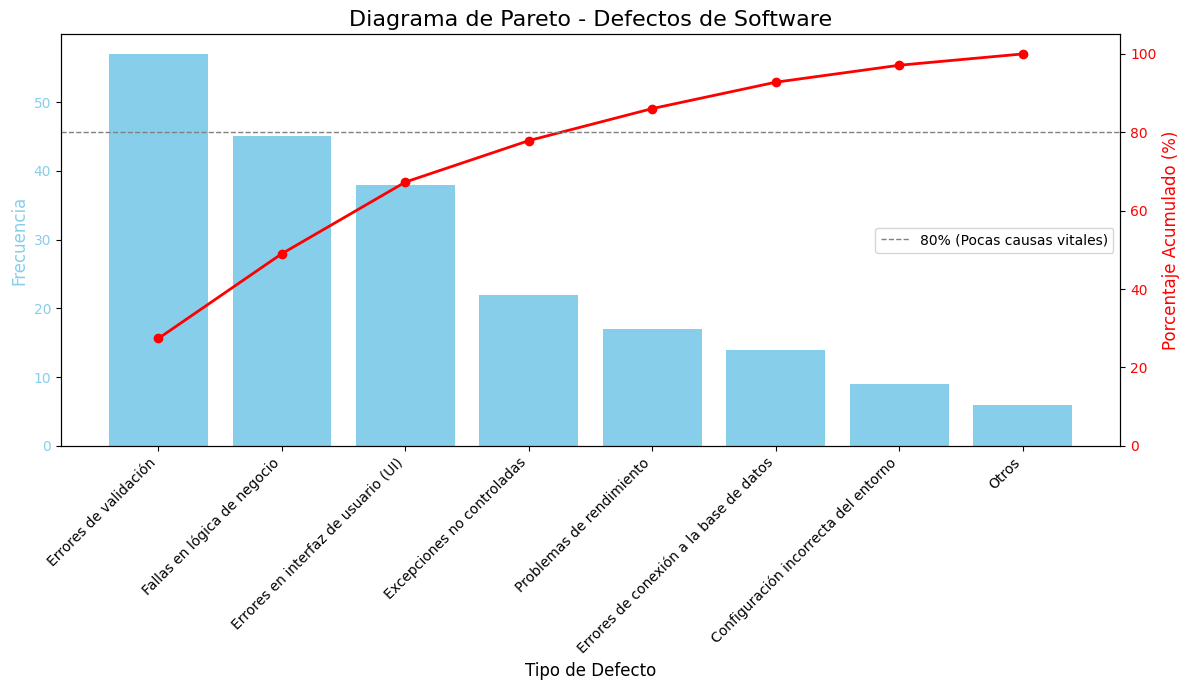

In [11]:
# Graficar gráfica de Pareto
fig, ax1 = plt.subplots(figsize=(12, 7))

# Gráfico de barras
ax1.bar(df_defects["Tipo de defecto"], df_defects["Frecuencia"], color="skyblue")
ax1.set_xlabel("Tipo de Defecto", fontsize=12)
ax1.set_ylabel("Frecuencia", color="skyblue", fontsize=12)
ax1.tick_params(axis='y', labelcolor="skyblue")
ax1.set_xticklabels(df_defects["Tipo de defecto"], rotation=45, ha='right', fontsize=10)

# Línea de porcentaje acumulado
ax2 = ax1.twinx()
ax2.plot(df_defects["Tipo de defecto"], df_defects["Porcentaje Acumulado"], color="red", marker="o", linewidth=2)
ax2.set_ylabel("Porcentaje Acumulado (%)", color="red", fontsize=12)
ax2.tick_params(axis='y', labelcolor="red")
ax2.set_ylim(0, 105) # Ajustar el límite superior para una mejor visualización

# Línea guía del 80%
ax2.axhline(y=80, color='gray', linestyle='--', linewidth=1, label='80% (Pocas causas vitales)')
ax2.legend(loc='center right')

plt.title("Diagrama de Pareto - Defectos de Software", fontsize=16)
plt.tight_layout()
plt.show()

1. Causas Vitales (≈80% del impacto): Errores de validación, Fallas en lógica de negocio, Errores en UI y Excepciones no controladas.

2. Impacto en el Proyecto:

Validación: Datos inconsistentes, fallos de seguridad.
Lógica de Negocio: Funcionamiento inesperado, afecta resultados.
UI: Deteriora la experiencia del usuario.
Excepciones: Causa inestabilidad, caídas de la aplicación, pérdida de datos.

3. Propuestas de Mejora:

Validación: Mejorar pruebas unitarias/integración, validaciones claras.
Lógica de Negocio: Reforzar requisitos, aumentar pruebas E2E, revisiones de código.
UI: Pruebas de usabilidad, automatización de pruebas de UI.
Excepciones: Manejo robusto de errores, mejor logging, capacitación en programación defensiva.